# Study 9: Forward Pass — P(p' | u)

Computes the full generative model prediction for each test feature:

$$P(p' \mid \vec{u}) = \int P(p' \mid y') \left[\int P(y', \vec{y} \mid \vec{u})\, d\vec{y}\right] dy'$$

- **P(y', ȳ | u)**: RSA speaker + GP prior, sampled via BlackJAX NUTS
- **P(p' | y')**: Beta mixture fit to participant prevalence ratings
- All training utterances are generic (u=0); test features have no utterance

In [1]:
import sys, csv, pickle as pkl
sys.path.insert(0, ".")

import numpy as np
import jax
import jax.numpy as jnp
import blackjax
import matplotlib.pyplot as plt

from model_jax import (
    make_log_density_fn,
    coherence_from_pseudocoherence,
    fit_beta_mixtures_all_features,
)

In [2]:
with open('../features/set2_features_dataframe.pkl', 'rb') as f:
    df = pkl.load(f)

with open('../../data/study9.csv') as f:
    rows = list(csv.reader(f))
CSV_HEADER = rows[0]
data_rows  = rows[3:]  # rows 0-2 are header/metadata

print(f"Features: {len(df)} total, {(df.split=='train').sum()} train, {(df.split=='test').sum()} test")
print(f"Participants: {len(data_rows)}")

Features: 60 total, 45 train, 15 test
Participants: 402


In [3]:
# CSV column → feature name in dataframe
CSV_TO_FEATURE = {
    'diet_can_eat_spicy_1':  'can eat spicy food',
    'diet_breakfast_late_1': 'eat breakfast very late',
    'diet_five_meals_day_1': 'eat five meals a day',
    'diet_like_juice_pulp_1':'like juice with pulp',
    'diet_pepper_on_all_1':  'put pepper on all their foods',
    'pers_cry_easily_1':     'cry easily',
    'pers_collect_rocks_1':  'like to collect rocks',
    'pers_like_to_dance_1':  'like to dance',
    'pers_like_highfive_1':  'like to give high-fives',
    'pers_read_books_1':     'like to read books',
    'phys_can_roll_tongue_1':'can roll their tongue',
    'phys_can_snap_toes_1':  'can snap with their toes',
    'phys_can_wiggle_ears_1':'can wiggle their ears',
    'phys_cold_hands_feet_1':'have cold hands and feet',
    'phys_snore_sleep_1':    'snore when they sleep',
}
TEST_CSV_COLS = list(CSV_TO_FEATURE.keys())  # J=15, ordered
feat_idx = df.set_index('feature')

train_df = df[df.split == 'train']
x_train  = jnp.array(train_df[['x_2d', 'y_2d']].values)          # (n_train, 2)
u_train  = jnp.zeros(len(train_df), dtype=jnp.int32)              # all generic

test_feature_names = [CSV_TO_FEATURE[c] for c in TEST_CSV_COLS]
x_test = jnp.array(
    [feat_idx.loc[name, ['x_2d', 'y_2d']].values for name in test_feature_names]
)  # (J, 2)

print(f"x_train: {x_train.shape}, x_test: {x_test.shape}")

x_train: (45, 2), x_test: (15, 2)


In [4]:
# Parse participant prevalence ratings → (N, J), scaled to [0, 1]
col_indices = [CSV_HEADER.index(c) for c in TEST_CSV_COLS]

ratings = []
for row in data_rows:
    try:
        vals = [int(row[i]) / 100.0 for i in col_indices]
        ratings.append(vals)
    except (ValueError, IndexError):
        pass  # skip rows with missing data

responses = jnp.array(ratings)  # (N, J)
N, J = responses.shape
print(f"responses: {responses.shape}  (N={N} participants, J={J} features)")
print(f"Mean rating per feature: {np.array(responses.mean(axis=0)).round(2)}")

responses: (402, 15)  (N=402 participants, J=15 features)
Mean rating per feature: [0.62 0.44 0.52 0.59 0.5  0.51 0.49 0.74 0.7  0.68 0.52 0.46 0.52 0.5
 0.54]


In [5]:
params = {
    'mu_0':         0.0,
    'length_scale': 0.4,
    'output_scale': 1.5,
    'beta':         3.0,
}

In [6]:
# MCMC: sample (y_train, y'_j) jointly for each test feature j
n_train   = x_train.shape[0]
n_warmup  = 500
n_samples = 2000
rng_key   = jax.random.PRNGKey(0)

pz1_test            = []  # P(z'=1 | u) posterior mean per test feature
pz1_samples_all     = []  # full (S,) sigmoid samples per test feature
test_coherences_all = []  # Phat(y'|u); y' samples per test feature

for j, (feat_name, x_prime) in enumerate(zip(test_feature_names, x_test)):
    log_density_fn = make_log_density_fn(u_train, x_train, x_prime, params)

    init_position = {
        'training_coherences': jnp.zeros(n_train),
        'test_coherence':      jnp.array(0.0),
    }

    rng_key, warmup_key = jax.random.split(rng_key)
    warmup = blackjax.window_adaptation(blackjax.nuts, log_density_fn)
    (state, nuts_params), _ = warmup.run(warmup_key, init_position, num_steps=n_warmup)

    nuts = blackjax.nuts(log_density_fn, **nuts_params)

    @jax.jit
    def one_step(state, key):
        return nuts.step(key, state)

    keys = jax.random.split(rng_key, n_samples)
    rng_key = keys[-1]
    test_coherences = []
    for key in keys[:-1]:
        state, _ = one_step(state, key)
        test_coherences.append(float(state.position['test_coherence']))

    test_coherences = np.array(test_coherences)
    test_coherences_all.append(test_coherences)

    pz1_s = np.array(jax.nn.sigmoid(jnp.array(test_coherences)))  # (S,)
    pz1_samples_all.append(pz1_s)

    pz1_j = float(np.mean(pz1_s))
    pz1_test.append(pz1_j)
    print(f"[{j+1:2d}/{J}] {feat_name:<35s}  P(z'=1) = {pz1_j:.3f}")

pz1_test = np.array(pz1_test)  # (J,)

[ 1/15] can eat spicy food                   P(z'=1) = 0.747
[ 2/15] eat breakfast very late              P(z'=1) = 0.733
[ 3/15] eat five meals a day                 P(z'=1) = 0.739
[ 4/15] like juice with pulp                 P(z'=1) = 0.779
[ 5/15] put pepper on all their foods        P(z'=1) = 0.725
[ 6/15] cry easily                           P(z'=1) = 0.776
[ 7/15] like to collect rocks                P(z'=1) = 0.766
[ 8/15] like to dance                        P(z'=1) = 0.800
[ 9/15] like to give high-fives              P(z'=1) = 0.758
[10/15] like to read books                   P(z'=1) = 0.753
[11/15] can roll their tongue                P(z'=1) = 0.800
[12/15] can snap with their toes             P(z'=1) = 0.741
[13/15] can wiggle their ears                P(z'=1) = 0.763
[14/15] have cold hands and feet             P(z'=1) = 0.761
[15/15] snore when they sleep                P(z'=1) = 0.768


## Posterior diagnostics: y' distributions per test feature

KDE of the MCMC samples for each test feature's pseudocoherence y'. Useful for checking whether the posterior is unimodal and roughly symmetric (Laplace-friendly) or multimodal/skewed.

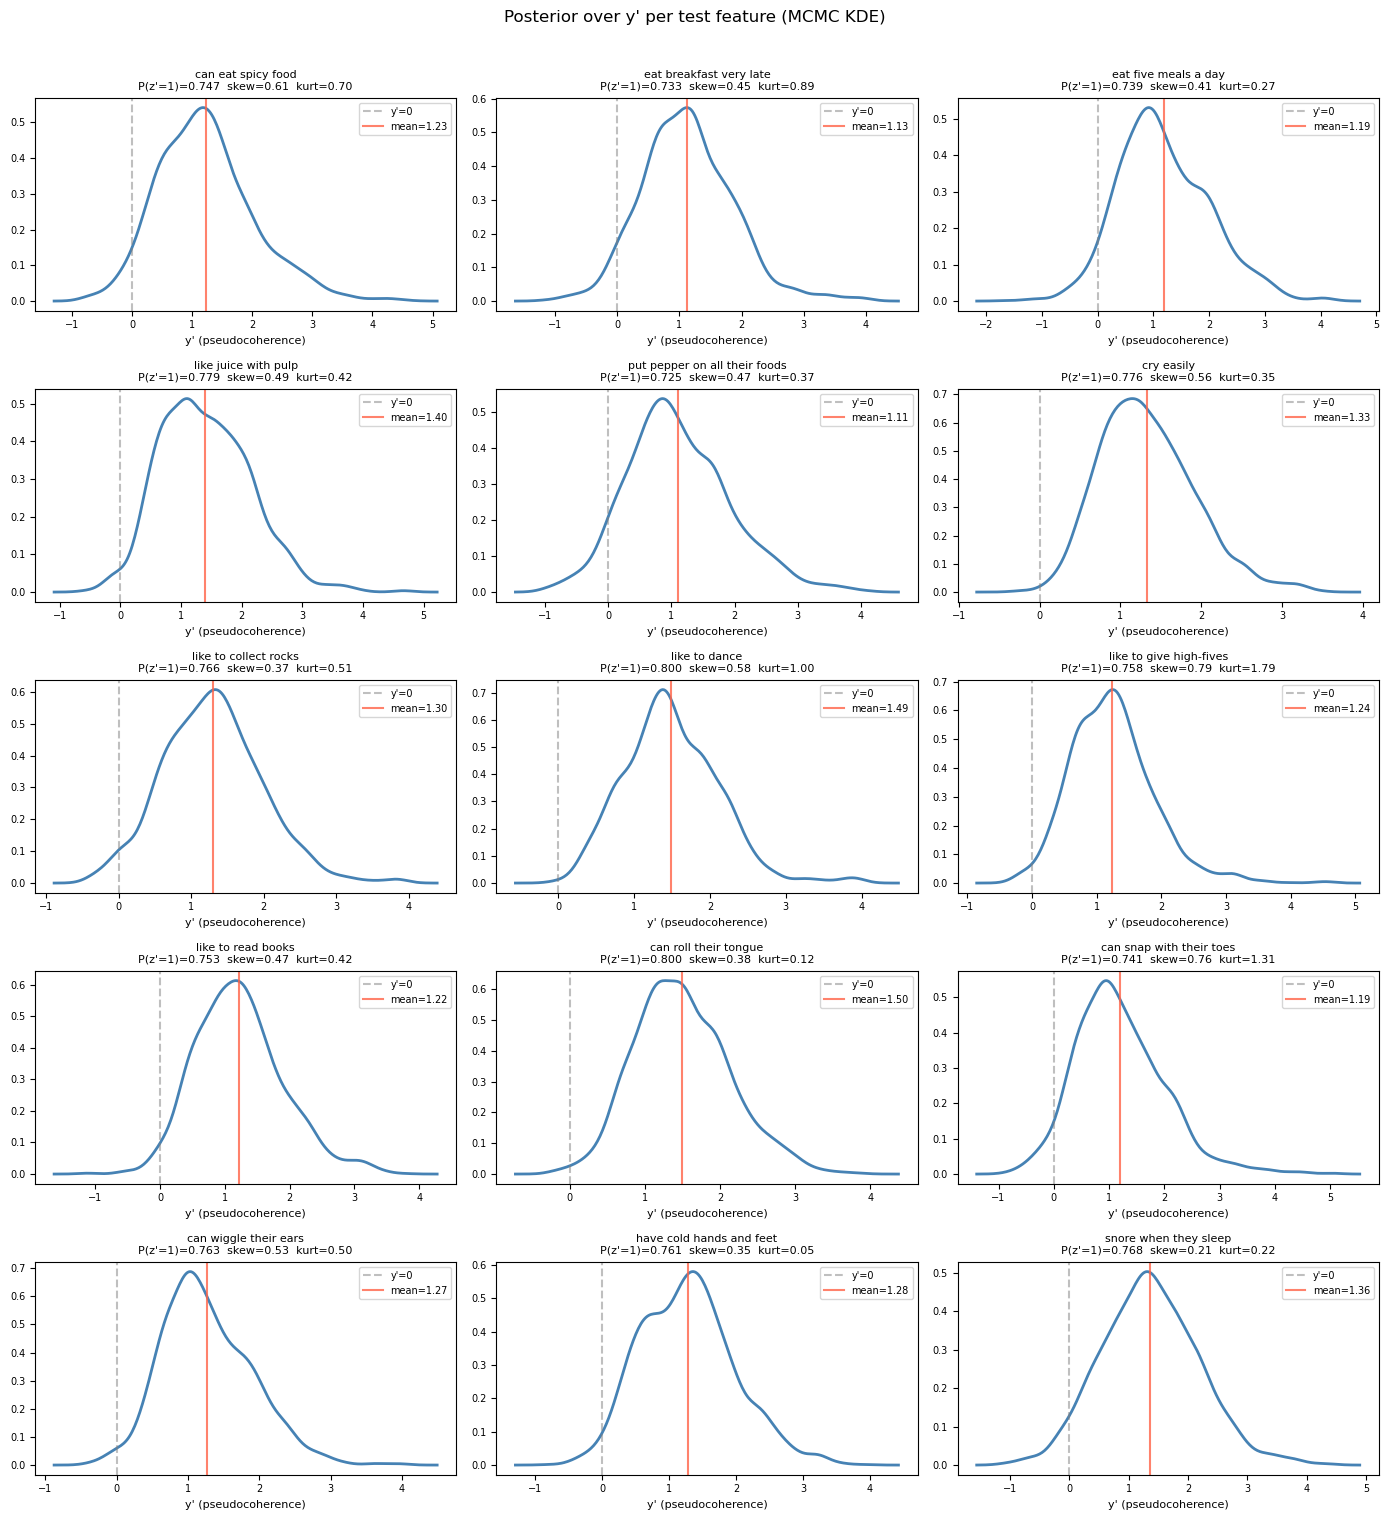

In [7]:
from scipy.stats import gaussian_kde

ncols = 3
nrows = (J + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3), sharey=False)
axes = axes.flatten()

for j, (feat_name, samples) in enumerate(zip(test_feature_names, test_coherences_all)):
    ax = axes[j]
    kde = gaussian_kde(samples)
    y_grid = np.linspace(samples.min() - 0.5, samples.max() + 0.5, 300)
    ax.plot(y_grid, kde(y_grid), lw=2, color='steelblue')
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5, label="y'=0")
    ax.axvline(np.mean(samples), color='tomato', linestyle='-', alpha=0.8, label=f"mean={np.mean(samples):.2f}")

    # skewness and excess kurtosis as quick multimodality proxies
    from scipy.stats import skew, kurtosis
    sk  = skew(samples)
    kurt = kurtosis(samples)  # excess kurtosis; >0 = heavier tails than Gaussian
    ax.set_title(f"{feat_name}\nP(z'=1)={pz1_test[j]:.3f}  skew={sk:.2f}  kurt={kurt:.2f}",
                 fontsize=8)
    ax.set_xlabel("y' (pseudocoherence)", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

for ax in axes[J:]:
    ax.set_visible(False)

plt.suptitle("Posterior over y' per test feature (MCMC KDE)", y=1.01)
plt.tight_layout()
plt.show()

In [8]:
import importlib
import model_jax
importlib.reload(model_jax)

# Fit Beta mixture P(p'|y') for each test feature.
# Each participant gets an independent draw from the posterior over pz1[j],
# propagating uncertainty about y' into the Beta params rather than collapsing to the mean.
rng_np = np.random.default_rng(0)
pz1_broadcast = jnp.array(
    np.stack([
        rng_np.choice(pz1_samples_all[j], size=N, replace=True)
        for j in range(J)
    ], axis=1)
)  # (N, J)

beta_params = model_jax.fit_beta_mixtures_all_features(responses, pz1_broadcast)
# beta_params: (J, 4) — [alpha_kl, beta_kl, alpha_nkl, beta_nkl]

alpha_kl, beta_kl, alpha_nkl, beta_nkl = (
    np.array(beta_params[:, i]) for i in range(4)
)
print("beta_params NaN?", np.isnan(beta_params).any())

beta_params NaN? False


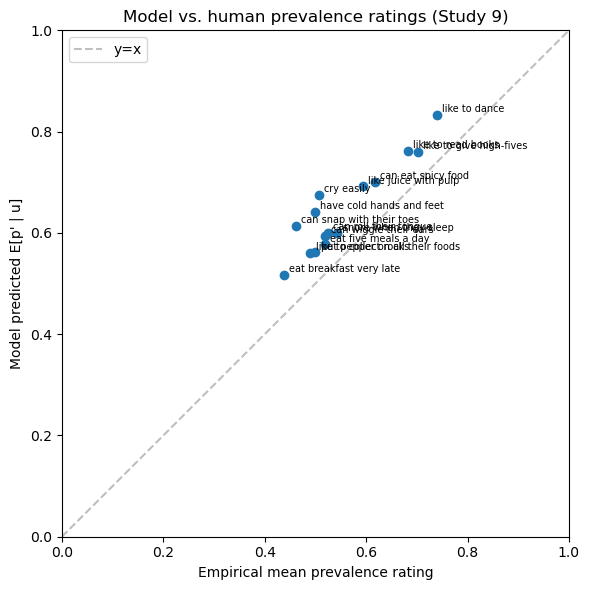

Pearson r = 0.921


In [9]:
# E[p' | u] = P(z'=1) * mean_kl + P(z'=0) * mean_nkl
mean_kl  = alpha_kl  / (alpha_kl  + beta_kl)
mean_nkl = alpha_nkl / (alpha_nkl + beta_nkl)
pred_prevalence = pz1_test * mean_kl + (1 - pz1_test) * mean_nkl  # E(p'|u), size (J,)

empirical_mean = np.array(responses.mean(axis=0))  # (J,)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(empirical_mean, pred_prevalence, zorder=3)
for j, name in enumerate(test_feature_names):
    ax.annotate(name, (empirical_mean[j], pred_prevalence[j]),
                fontsize=7, xytext=(4, 2), textcoords='offset points')
lims = [0, 1]
ax.plot(lims, lims, '--', color='gray', alpha=0.5, label='y=x')
ax.set_xlabel('Empirical mean prevalence rating')
ax.set_ylabel('Model predicted E[p\' | u]')
ax.set_title('Model vs. human prevalence ratings (Study 9)')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.legend()
plt.tight_layout()
plt.show()

corr = np.corrcoef(empirical_mean, pred_prevalence)[0, 1]
print(f"Pearson r = {corr:.3f}")